* ## Angélica Vanegas C.C 1000290572

In [54]:
# Import numpy and pandas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd;
print("Este es pandas version\n ",pd.__version__)

Este es pandas version
  2.2.2


## Example 2: Análisis exploratorio de datos con PANDAS y NUMPY

Esta clase será trabajada mediante la respuesta a algunos ejercicios planteados a continuación. Para ello, trabajaremos con un conjunto de datos que podemos cargar ejecutando las siguientes líneas de código.

In [33]:
import seaborn as sns

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [4]:
len(df)

333

Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

# Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



# Solución:

## 1. Realizamos una selección en el Dataframe para separar los pinguinos de la isla Torgersen y con esta hallamos los datos de las profundidades máxima y mínima del pico.

In [70]:
df_torgersen = df[df["isla"] == "Torgersen"]
print(f"La profundidad de pico máxima en la isla de Torgersen es: {df_torgersen["profundidad_pico (mm)"].max()} y la mínima: {df_torgersen["profundidad_pico (mm)"].min()}")
df_torgersen[:5]

La profundidad de pico máxima en la isla de Torgersen es: 21.5 y la mínima: 15.9


,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## 2. numpy.argmax() returns the indices of the maximum values along an axis.

  https://numpy.org/doc/2.2/reference/generated/numpy.argmax.html

In [43]:
posicion = df["masa_corporal (g)"].argmax()
pinguino = df.iloc[posicion]
print(f"El pinguino con la mayor masa corporal esá en la posición {posicion} del DataFrame, está ubicado en la isla {pinguino["isla"]}, su especie es {pinguino["especie"]} y su género es {pinguino["genero"]}")
pinguino

El pinguino con la mayor masa corporal esá en la posición 231 del DataFrame, está ubicado en la isla Biscoe, su especie es Gentoo y su género es Male


,231
especie,Gentoo
isla,Biscoe
longitud_pico (mm),49.2
profundidad_pico (mm),15.2
longitud_aleta (mm),221.0
masa_corporal (g),6300.0
genero,Male


## 3. Vamos a hacer un filtro donde se tomen todos los machos y se excluyan los de la especie Gentoo

In [53]:
filtro = df[(df["genero"] == "Male") & (df["especie"] != "Gentoo")]
print(f"La masa corporal promedio de los machos que no la especie Gentoo es: {filtro["masa_corporal (g)"].mean()} g")

La masa corporal promedio de los machos que no la especie Gentoo es: 4010.2803738317757 g


## 4. numpy.histogram compute the histogram of a dataset.

https://numpy.org/doc/2.2/reference/generated/numpy.histogram.html

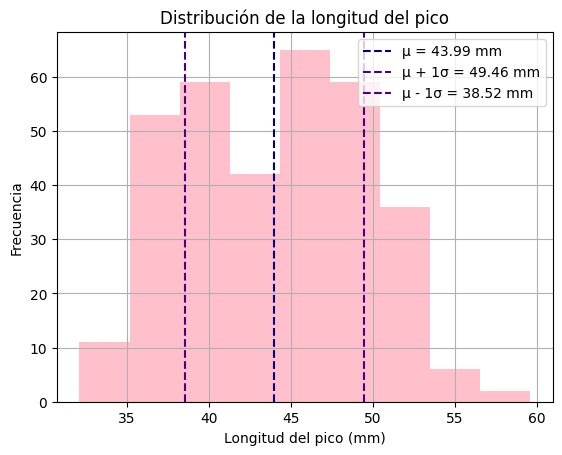

In [113]:
numero_bins = int(1 + np.log2(len(df)))
media = df["longitud_pico (mm)"].mean()
std = df["longitud_pico (mm)"].std()
df["longitud_pico (mm)"].hist(bins = numero_bins, color = "pink")
plt.axvline(media, linestyle="--", color = "navy", label = f"μ = {round(media, 2)} mm")
plt.axvline(media + std, linestyle="--", color = "indigo", label = f"μ + 1σ = {round(media + std, 2)} mm")
plt.axvline(media - std, linestyle="--", color = "indigo", label = f"μ - 1σ = {round(media - std, 2)} mm")
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la longitud del pico")
plt.legend()
plt.show()

## 5. Tipos de islas y especies y su frecuencia.

Para eso usamos la función pandas.Series.value_counts() y después vamos a graficarlos

https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html


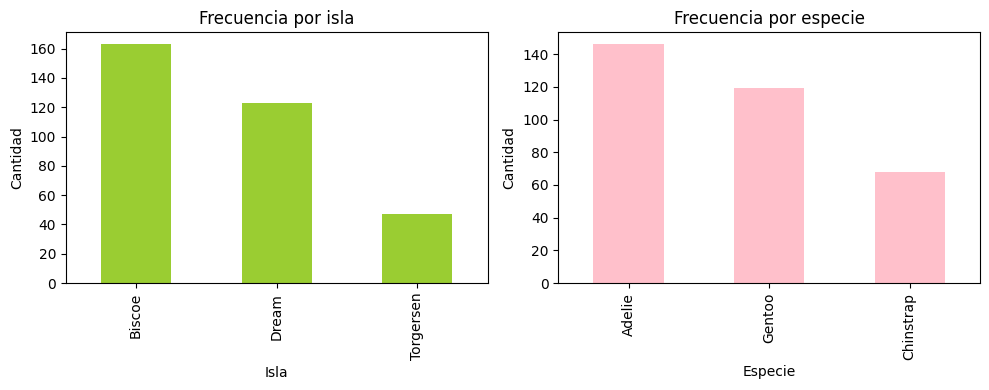

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

df["isla"].value_counts().plot(kind="bar", color = "yellowgreen", ax=ax[0])
ax[0].set_title("Frecuencia por isla")
ax[0].set_xlabel("Isla")
ax[0].set_ylabel("Cantidad")

df["especie"].value_counts().plot(kind="bar", color = "pink", ax=ax[1])
ax[1].set_title("Frecuencia por especie")
ax[1].set_xlabel("Especie")
ax[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

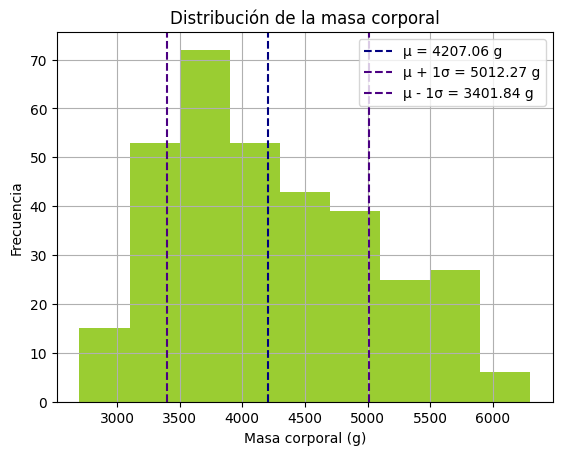

In [114]:
media2 = df["masa_corporal (g)"].mean()
std2 = df["masa_corporal (g)"].std()
df["masa_corporal (g)"].hist(bins = numero_bins, color = "yellowgreen")
plt.axvline(media2, linestyle="--", color = "navy", label = f"μ = {round(media2, 2)} g")
plt.axvline(media2 + std2, linestyle="--", color = "indigo", label = f"μ + 1σ = {round(media2 + std2, 2)} g")
plt.axvline(media2 - std2, linestyle="--", color = "indigo", label = f"μ - 1σ = {round(media2 - std2, 2)} g")
plt.xlabel("Masa corporal (g)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la masa corporal")
plt.legend()
plt.show()